In [49]:
import os
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split,StratifiedKFold,cross_val_score
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,classification_report,
    confusion_matrix
)

load the data

In [50]:
df = pd.read_csv("data/titanic.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Inspection of data, Note the missing values

In [51]:
print("shape: ",df.shape)
print("\nColumns: ",list(df.columns))
print("\nMissing values per columns: ")
print(df.isnull().sum())
print("\nPercentage of missing values per column: ")
print(df.isnull().mean()*100)

shape:  (891, 12)

Columns:  ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Missing values per columns: 
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Percentage of missing values per column: 
PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64


In [52]:
print(df['Survived'].value_counts())
print("\nOverall survival Rate: ",round(df['Survived'].mean()*100,3),"%")

Survived
0    549
1    342
Name: count, dtype: int64

Overall survival Rate:  38.384 %


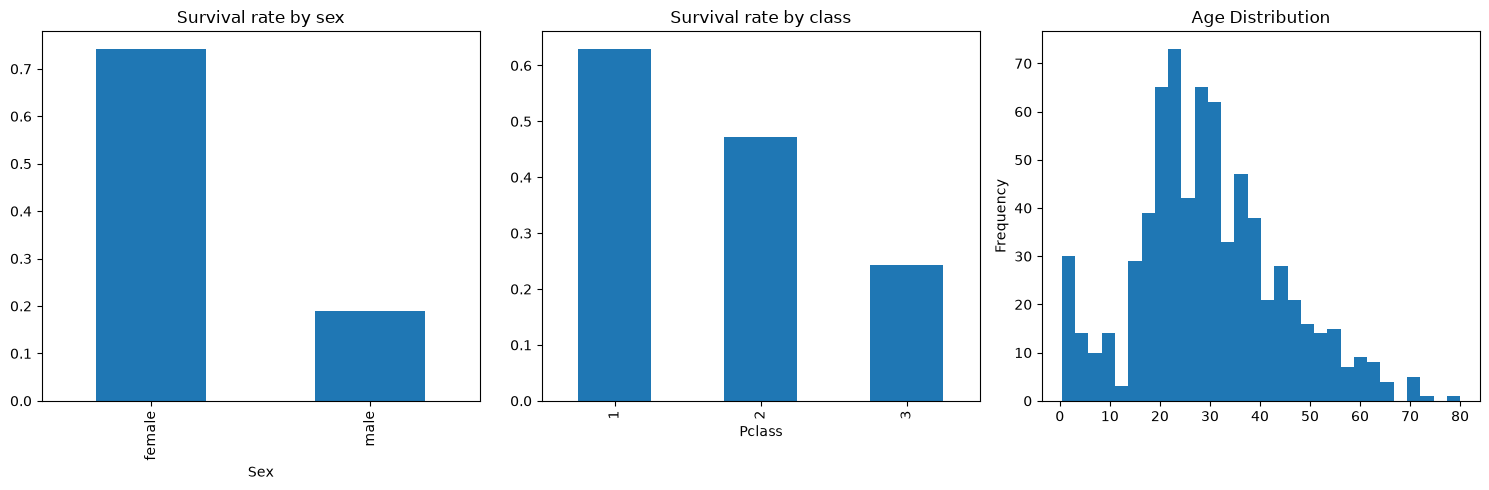

In [53]:
fig,axes = plt.subplots(1,3,figsize=(15,5))
df.groupby('Sex')['Survived'].mean().plot(kind='bar',ax=axes[0],title="Survival rate by sex")
df.groupby('Pclass')['Survived'].mean().plot(kind='bar',ax=axes[1],title="Survival rate by class")
df['Age'].plot(kind='hist',bins=30,ax=axes[2],title='Age Distribution')
plt.tight_layout()
plt.show()

In [54]:
target = 'Survived'
drop_cols = ['PassengerId','Name','Ticket','Cabin']

X = df.drop(columns=[target] + drop_cols)
y = df[target]

In [55]:
print("Feature used: ",list(X.columns))

Feature used:  ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


In [56]:
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


In [57]:
numeric_features = ['Age','SibSp','Parch','Fare']
categorical_features = ['Pclass','Sex','Embarked']

Build preprocessing Pipline

In [58]:
numeric_transformer = Pipeline(steps=[
    ("imputer",SimpleImputer(strategy='median')),
    ("scaler",StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer",SimpleImputer(strategy='most_frequent')),
    ("onehot",OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ("num",numeric_transformer,numeric_features),
    ("cat",categorical_transformer,categorical_features)
])

model = Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("classifier",LogisticRegression(max_iter=1000,random_state=42))
])

In [59]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y
)

print("Train: ",X_train.shape[0],"| Test: ",X_test.shape[0])

Train:  712 | Test:  179


In [60]:
model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['Pclass','Sex','Age',...,'Parch','Fare','Embarked']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining column

In [61]:
y_pred = model.predict(X_test)

print(f"Test accuracy: {round(accuracy_score(y_test,y_pred)*100,2)}%\n")
print("Classification Report: ")
print(classification_report(y_test,y_pred,target_names=['Died','Survived']))

Test accuracy: 80.45%

Classification Report: 
              precision    recall  f1-score   support

        Died       0.81      0.89      0.85       110
    Survived       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



In [62]:
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
scores = cross_val_score(model,X,y,cv=cv,scoring='accuracy')
print("Per-fold Accuracy: ",scores.round(3))
print("Mean CV Accuracy: ",scores.mean().round(3))

Per-fold Accuracy:  [0.782 0.803 0.798 0.781 0.82 ]
Mean CV Accuracy:  0.797


In [63]:
os.makedirs("model",exist_ok=True)

In [64]:
joblib.dump(model,"model/titanic_pipeline.joblib")
print("Saved-> model/titanic_pipeline.jobline")

Saved-> model/titanic_pipeline.jobline


Reload the model and verify

In [71]:
loaded = joblib.load("model/titanic_pipeline.joblib")

sample = pd.DataFrame([{
    "Pclass":3,'Sex':"male","Age":22.0,
    "SibSp":1,"Parch":0,'Fare':7.34,'Embarked':"S"
}])

pred = int(loaded.predict(sample)[0])
proba = float(loaded.predict_proba(sample)[0][pred])
label = "Survived" if pred == 1 else "Did not survive"
print(f"Prediction: {pred} ({label}) | Probability: {round(proba,3)}")


Prediction: 0 (Did not survive) | Probability: 0.912
